In [1]:
from google.colab import drive     # Conectar a Google drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
import pandas as pd
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!pip install easy_mpl
from easy_mpl import taylor_plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 6.4 MB/s eta 0:00:00


In [4]:
df_region = pd.read_excel("/content/drive/MyDrive/4Students_2026/Data/Selva/Datos_completos/datos_completos_Selva.xlsx")
df_region.head()

,Fecha,tmax_obs,tmin_obs,pp_obs,tmax,tmin,pp,Tmax_origen,Tmax_completo,Tmin_origen,Tmin_completo,Pp_origen,Pp_completo,Codigo,Nombre,Latitud,Longitud,Altitud (msnm)
0,1965-01-01,30.5,NaN,0.0,NaN,NaN,NaN,obs,30.5,sin_dato,NaN,obs,0.0,ho00000833,APLAO,-16.069,-72.491,645
1,1965-01-02,29.6,NaN,0.0,NaN,NaN,NaN,obs,29.6,sin_dato,NaN,obs,0.0,ho00000833,APLAO,-16.069,-72.491,645
2,1965-01-03,27.8,NaN,0.0,NaN,NaN,NaN,obs,27.8,sin_dato,NaN,obs,0.0,ho00000833,APLAO,-16.069,-72.491,645
3,1965-01-04,30.9,NaN,0.0,NaN,NaN,NaN,obs,30.9,sin_dato,NaN,obs,0.0,ho00000833,APLAO,-16.069,-72.491,645
4,1965-01-05,31.0,NaN,0.0,NaN,NaN,NaN,obs,31.0,sin_dato,NaN,obs,0.0,ho00000833,APLAO,-16.069,-72.491,645


# Diagram de Taylor de 1 solo modelo: comparar técnicas (EQM, SCALING, QDM)

In [5]:
codigo = 'ho00000830' #ELIJEN UNA ESTACION
df_obs_estacion = df_region[df_region['Codigo'] == codigo].copy()
df_obs_estacion['Fecha'] = pd.to_datetime(df_obs_estacion['Fecha'])
df_obs_estacion.set_index('Fecha', inplace=True)
df_obs_estacion.head()

,tmax_obs,tmin_obs,pp_obs,tmax,tmin,pp,Tmax_origen,Tmax_completo,Tmin_origen,Tmin_completo,Pp_origen,Pp_completo,Codigo,Nombre,Latitud,Longitud,Altitud (msnm)
Fecha,,,,,,,,,,,,,,,,,
1965-01-01,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000830,PUNTAATICO,-16.229,-73.694,20
1965-01-02,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000830,PUNTAATICO,-16.229,-73.694,20
1965-01-03,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000830,PUNTAATICO,-16.229,-73.694,20
1965-01-04,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000830,PUNTAATICO,-16.229,-73.694,20
1965-01-05,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000830,PUNTAATICO,-16.229,-73.694,20


In [6]:
serie_observada_var = df_obs_estacion['Pp_completo'] #ELIJEN UNA VARIABLE, YO HE TRABAJADO CON PP
serie_observada_var.head()

,Pp_completo
Fecha,
1965-01-01,NaN
1965-01-02,NaN
1965-01-03,NaN
1965-01-04,NaN
1965-01-05,NaN


In [7]:
ruta_mod1 = "/content/drive/MyDrive/4Students_2026/Data/Selva/Downscalling/Downscalling_ssp2_4.5_pp_ACCESS-CM2_ho00000830.csv" #UN ESCENARIO PP
df_mod = pd.read_csv(ruta_mod1)
df_mod['date'] = pd.to_datetime(df_mod['date'])
df_mod.set_index('date', inplace=True)
df_mod.head()

,eqm,scaling,qdm
date,,,
1981-01-01,0.0,0.021424,0.0
1981-01-02,0.0,0.023379,0.0
1981-01-03,0.0,0.004890,0.0
1981-01-04,0.0,0.001775,0.0
1981-01-05,0.0,0.000357,0.0


In [8]:
indices_comunes = serie_observada_var.index.intersection(df_mod.index)
serie_obs_sync = serie_observada_var.loc[indices_comunes].squeeze()
serie_obs_sync.head()

,Pp_completo
1981-01-01,0.005763
1981-01-02,0.013763
1981-01-03,0.004627
1981-01-04,0.004587
1981-01-05,0.028733


In [9]:
df_mod.isna().sum()

,0
eqm,0
scaling,0
qdm,0


In [10]:
serie_obs_sync.isna().sum()

np.int64(367)

In [11]:
# Unimos las observaciones y los 3 métodos en un solo DataFrame temporal
df_temp = pd.concat([
    serie_obs_sync.rename('Observado'),
    df_mod.loc[indices_comunes, ['eqm', 'scaling', 'qdm']]
], axis=1)
df_temp = df_temp.loc['1981-01-01':'2014-12-31']
# Borramos CUALQUIER fila que tenga un NaN (así garantizamos que se comparan los mismos días exactos)
df_temp_limpio = df_temp.dropna()

print(f"Días originales: {len(df_temp)} | Días tras borrar NaNs: {len(df_temp_limpio)}")

Días originales: 12418 | Días tras borrar NaNs: 12418


In [12]:
# Extraemos la serie observada ya limpia
serie_obs_limpia = df_temp_limpio['Observado']

# Creamos el diccionario con los métodos ya limpios
diccionario_metodos_limpio = {
    'EQM': df_temp_limpio['eqm'],
    'Scaling': df_temp_limpio['scaling'],
    'QDM': df_temp_limpio['qdm']
}

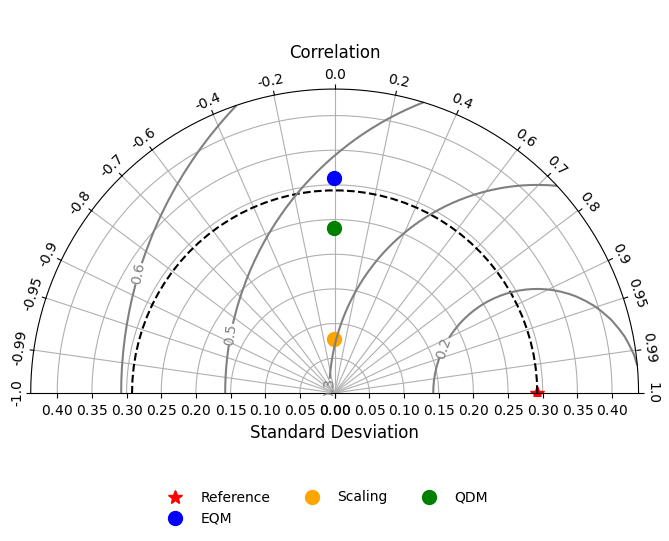

<Figure size 640x480 with 0 Axes>

In [13]:
fig, ax = plt.subplots(figsize=(7, 8))
colores = ['blue', 'orange', 'green']
estilo_titulos = {
    'top': {'color': 'black', 'fontsize': 12, 'weight': 'bold'},
    'bottom': {'color': 'darkred', 'fontsize': 11, 'weight': 'bold'},
    'left': {'color': 'darkred', 'fontsize': 11, 'weight': 'bold'}
}
config_leyenda = {'loc': 'upper center', 'bbox_to_anchor': (0.5, 0.1), 'ncol': 3, 'frameon': False}

taylor_plot(
    observations=serie_obs_limpia,          # <--- Usamos la versión limpia
    simulations=diccionario_metodos_limpio, # <--- Usamos la versión limpia
    extend=True,
    corr_alias='Correlation',
    std_alias='Standard Desviation',
    ax=ax,
    leg_kws=config_leyenda,
    axis_fontdict=estilo_titulos,
    colors=colores
)
plt.subplots_adjust(bottom=0.25)
plt.show()

# Diagrama Taylor de varios modelos: Comparar modelos

In [14]:
serie_observada_var.head()

,Pp_completo
Fecha,
1965-01-01,NaN
1965-01-02,NaN
1965-01-03,NaN
1965-01-04,NaN
1965-01-05,NaN


In [15]:
df_mod.head()

,eqm,scaling,qdm
date,,,
1981-01-01,0.0,0.021424,0.0
1981-01-02,0.0,0.023379,0.0
1981-01-03,0.0,0.004890,0.0
1981-01-04,0.0,0.001775,0.0
1981-01-05,0.0,0.000357,0.0


In [16]:
ruta_mod2 = "/content/drive/MyDrive/4Students_2026/Data/Selva/Downscalling/Downscalling_ssp2_4.5_pp_KACE-1-0-G_ho00000837.csv"
df_mod2 = pd.read_csv(ruta_mod2)
df_mod2['date'] = pd.to_datetime(df_mod2['date'])
df_mod2.set_index('date', inplace=True)
df_mod2.head()

,eqm,scaling,qdm
date,,,
1981-01-01,0.0,0.034780,0.000000
1981-01-02,0.0,0.101225,0.111675
1981-01-03,0.0,0.045500,0.000000
1981-01-04,0.0,0.021060,0.000000
1981-01-05,0.0,0.016005,0.000000


In [17]:
tecnica = "eqm"
df_unido = pd.concat([
    serie_observada_var,
    df_mod[tecnica].rename('ACCESS-CM2'),
    df_mod2[tecnica].rename('KACE-1-0-G')
], axis=1)

# Filtramos estrictamente el periodo histórico
df_unido = df_unido.loc['1981-01-01':'2014-12-31']

# Borramos los días vacíos
df_limpio = df_unido.dropna()
print(f"Días válidos para Met 2 (1981-2014): {len(df_limpio)}")

Días válidos para Met 2 (1981-2014): 12180


In [18]:
serie_obs_limpia = df_limpio['Pp_completo']

diccionario_simulaciones = {
    'ACCESS-CM2': df_limpio['ACCESS-CM2'],
    'KACE-1-0-G': df_limpio['KACE-1-0-G']
}

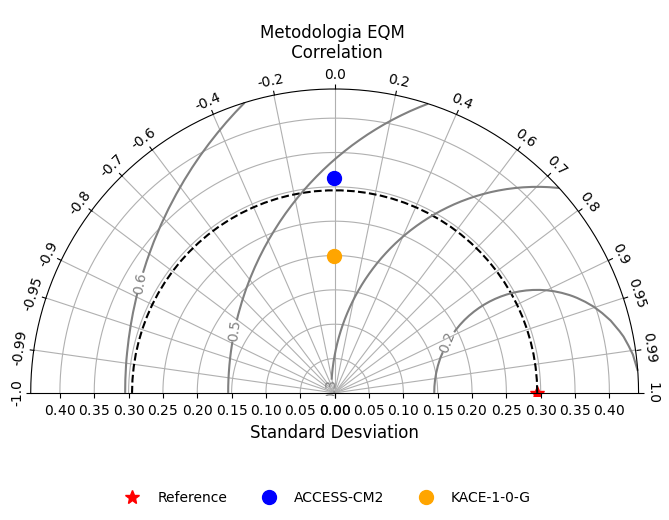

<Figure size 640x480 with 0 Axes>

In [19]:
taylor_plot(
    observations=serie_obs_limpia,
    simulations=diccionario_simulaciones,
    extend=True,
    corr_alias='Metodologia EQM \n Correlation',
    std_alias='Standard Desviation',
    ax=ax,
    leg_kws=config_leyenda,
    axis_fontdict=estilo_titulos,
    colors=colores
)
plt.subplots_adjust(bottom=0.25)
plt.show()

# Diagrama Taylor observar varios modelos y tecnicas

In [20]:
# Identificamos la estación
codigo_est = 'ho00000830'

# Extraemos la observación y limpiamos el índice
df_obs_est = df_region[df_region['Codigo'] == codigo_est].copy()
df_obs_est['Fecha'] = pd.to_datetime(df_obs_est['Fecha'])
df_obs_est.set_index('Fecha', inplace=True)
serie_obs = df_obs_est['Pp_completo'].rename('Observado')

In [21]:
# Modelo 1: ACCESS-CM2
df_mod1 = pd.read_csv(ruta_mod1)
df_mod1['date'] = pd.to_datetime(df_mod1['date'])
df_mod1.set_index('date', inplace=True)
df_mod1 = df_mod1[['eqm', 'scaling', 'qdm']].rename(columns={
    'eqm': 'ACC_eqm', 'scaling': 'ACC_scal', 'qdm': 'ACC_qdm'
})

# Modelo 2: KACE-1-0-G
df_mod2 = pd.read_csv(ruta_mod2)
df_mod2['date'] = pd.to_datetime(df_mod2['date'])
df_mod2.set_index('date', inplace=True)
df_mod2 = df_mod2[['eqm', 'scaling', 'qdm']].rename(columns={
    'eqm': 'KACE_eqm', 'scaling': 'KACE_scal', 'qdm': 'KACE_qdm'
})

In [22]:
# Unimos todo: 1 columna de obs + 9 columnas de modelos/métodos
df_unido = pd.concat([serie_obs, df_mod1, df_mod2], axis=1)

# Filtro estricto del periodo histórico (1981-2014)
df_unido = df_unido.loc['1981-01-01':'2014-12-31']

# Borramos filas con cualquier NaN para asegurar sincronización perfecta
df_limpio = df_unido.dropna()
print(f"Días sincronizados para el Taylor (9 variables): {len(df_limpio)}")

Días sincronizados para el Taylor (9 variables): 12180


In [23]:
# Separar la observación limpia
serie_obs_final = df_limpio['Observado']

# Crear el diccionario con las 9 combinaciones
diccionario_9 = {col: df_limpio[col] for col in df_limpio.columns if col != 'Observado'}

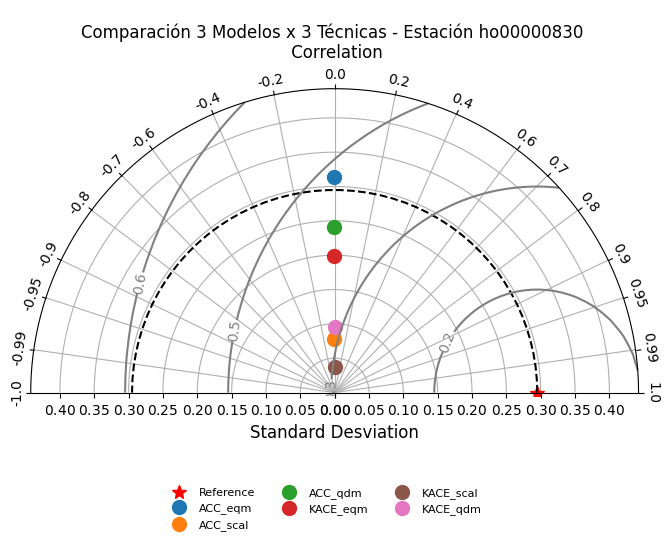

<Figure size 640x480 with 0 Axes>

In [24]:
# Configuración del gráfico
fig, ax = plt.subplots(figsize=(8, 9))

# Usamos una paleta de 10 colores para que los 9 puntos sean distintos
colores_9 = plt.cm.tab10(np.linspace(0, 1, 9))

estilo_titulos = {
    'top': {'color': 'black', 'fontsize': 12, 'weight': 'bold'},
    'bottom': {'color': 'darkred', 'fontsize': 11, 'weight': 'bold'},
    'left': {'color': 'darkred', 'fontsize': 11, 'weight': 'bold'}
}

# Leyenda configurada en 3 columnas para que no ocupe tanto espacio hacia abajo
config_leyenda = {
    'loc': 'upper center',
    'bbox_to_anchor': (0.5, 0.1),
    'ncol': 3,
    'fontsize': 8,
    'frameon': False
}

taylor_plot(
    observations=serie_obs_final,
    simulations=diccionario_9,
    extend=True,
    corr_alias=f'Comparación 3 Modelos x 3 Técnicas - Estación {codigo_est} \n Correlation',
    std_alias='Standard Desviation',
    ax=ax,
    leg_kws=config_leyenda,
    axis_fontdict=estilo_titulos,
    colors=colores_9
)

plt.subplots_adjust(bottom=0.25)
plt.show()

# AUTOMATIZADO

In [25]:
df_sierra = pd.read_csv("/content/drive/MyDrive/4Students_2026/Data/Sierra_Norte/Estaciones/Datos_completosdatos_completos_Sierra_Norte.csv")
df_sierra.head()

,Fecha,tmax_obs,tmin_obs,pp_obs,tmax,tmin,pp,Tmax_origen,Tmax_completo,Tmin_origen,Tmin_completo,Pp_origen,Pp_completo,Codigo,Nombre,Latitud,Longitud,Altitud (msnm)
0,1965-01-01,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000304,AUGUSTOWEBERBAUER,-7.167,-78.485,2660
1,1965-01-02,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000304,AUGUSTOWEBERBAUER,-7.167,-78.485,2660
2,1965-01-03,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000304,AUGUSTOWEBERBAUER,-7.167,-78.485,2660
3,1965-01-04,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000304,AUGUSTOWEBERBAUER,-7.167,-78.485,2660
4,1965-01-05,NaN,NaN,NaN,NaN,NaN,NaN,sin_dato,NaN,sin_dato,NaN,sin_dato,NaN,ho00000304,AUGUSTOWEBERBAUER,-7.167,-78.485,2660


In [26]:
def generar_taylor_met4_masivo(ruta_carpeta, df_obs_completo, codigo_estacion, variable, escenario, save_path=None):
    """
    Metodología 4: Genera un Diagrama de Taylor comparando TODAS las técnicas (EQM, Scaling, QDM)
    de TODOS los modelos disponibles para una estación, variable y escenario específicos.
    Filtra estrictamente para el periodo 1981-2014.
    """
    print(f"\n--- Iniciando Met 4: {codigo_estacion} | {variable.upper()} | {escenario.upper()} ---")

    # 1. Identificar la columna de observación correcta
    mapa_obs = {'pp': 'Pp_completo', 'tmax': 'Tmax_completo', 'tmin': 'Tmin_completo'}
    col_obs = mapa_obs.get(variable.lower())

    if not col_obs:
        print(f"❌ Variable '{variable}' no válida.")
        return

    # 2. Preparar la Observación
    df_estacion = df_obs_completo[df_obs_completo['Codigo'] == codigo_estacion].copy()
    if df_estacion.empty:
        print(f"❌ No se hallaron datos observados para la estación {codigo_estacion}")
        return

    # EXTRAEMOS EL NOMBRE DE LA ESTACIÓN
    nombre_estacion = df_estacion['Nombre'].iloc[0]

    df_estacion['Fecha'] = pd.to_datetime(df_estacion['Fecha'])
    df_estacion.set_index('Fecha', inplace=True)
    serie_obs = df_estacion[col_obs].rename('Observado')

    # 3. Buscar archivos de los modelos usando el patrón
    patron_busqueda = os.path.join(ruta_carpeta, f"Downscalling_{escenario}_{variable}_*_{codigo_estacion}.csv")
    archivos_modelos = glob.glob(patron_busqueda)

    if not archivos_modelos:
        print(f"❌ No se encontraron simulaciones para el patrón: {patron_busqueda}")
        return

    # 4. Leer todos los modelos y preparar sus columnas
    lista_dataframes = [serie_obs]

    for archivo in archivos_modelos:
        # Extraer el nombre del modelo del nombre del archivo
        nombre_archivo = os.path.basename(archivo)
        modelo = nombre_archivo.replace(f"Downscalling_{escenario}_{variable}_", "").replace(f"_{codigo_estacion}.csv", "")

        # Cargar el CSV
        df_mod = pd.read_csv(archivo)
        df_mod['date'] = pd.to_datetime(df_mod['date'])
        df_mod.set_index('date', inplace=True)

        # Quedarnos solo con las 3 técnicas y renombrarlas para la leyenda
        df_tecnicas = df_mod[['eqm', 'scaling', 'qdm']].copy()
        df_tecnicas = df_tecnicas.rename(columns={
            'eqm': f"{modelo} - EQM",
            'scaling': f"{modelo} - SCALING",
            'qdm': f"{modelo} - QDM"
        })

        lista_dataframes.append(df_tecnicas)
        print(f"✅ Modelo cargado: {modelo}")

    # 5. Unir todo, filtrar periodo histórico (1981-2014) y limpiar NaNs
    df_unido = pd.concat(lista_dataframes, axis=1)
    df_unido = df_unido.loc['1981-01-01':'2014-12-31']
    df_limpio = df_unido.dropna()

    num_puntos = len(df_limpio.columns) - 1 # Restamos 1 por la columna de observación
    print(f"📊 Evaluando {num_puntos} técnicas en total. Días válidos sincronizados: {len(df_limpio)}")

    if len(df_limpio) < 30:
        print("❌ Demasiados datos faltantes al sincronizar, no se puede graficar.")
        return

    # 6. Preparar datos para el Diagrama de Taylor
    serie_obs_final = df_limpio['Observado']
    diccionario_simulaciones = {col: df_limpio[col] for col in df_limpio.columns if col != 'Observado'}

    # 7. Graficar
    fig, ax = plt.subplots(figsize=(9, 10)) # Un poco más alto para dejar espacio a la leyenda grande

    # Paleta dinámica (tab20) para asegurar que haya colores distintos aunque tengas 15 puntos
    colores = plt.cm.tab20(np.linspace(0, 1, num_puntos))

    estilo_titulos = {
        'top': {'color': 'black', 'fontsize': 12, 'weight': 'bold'},
        'bottom': {'color': 'darkred', 'fontsize': 11, 'weight': 'bold'},
        'left': {'color': 'darkred', 'fontsize': 11, 'weight': 'bold'}
    }

    config_leyenda = {
        'loc': 'upper center',
        'bbox_to_anchor': (0.5, 0.1),
        'ncol': 3,
        'fontsize': 9,
        'frameon': False
    }

    titulo_curvo = f"Diagrama Taylor | {variable.upper()} | {escenario.upper()} \n Estación: {nombre_estacion} ({codigo_estacion}) \n \n Correlación"

    taylor_plot(
        observations=serie_obs_final,
        simulations=diccionario_simulaciones,
        extend=True,
        corr_alias= titulo_curvo,
        std_alias='Desviación estándar',
        ax=ax,
        leg_kws=config_leyenda,
        axis_fontdict=estilo_titulos,
        colors=colores
    )

    plt.subplots_adjust(bottom=0.30) # Espacio generoso abajo para las 3 columnas de leyenda

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✨ Gráfico guardado localmente como: {save_path}")

    plt.show()

In [27]:
df_sierra["Codigo"].unique()

array(['ho00000304', 'ho00000237', 'ho00000362', 'ho00000373',
       'ho00000354', 'ho00000352', 'ho00000343', 'ho00000239',
       'ho00000248', 'ho00000307', 'ho00000341', 'ho00000388',
       'ho00000321', 'ho00000369', 'ho00000370', 'ho00000351'],
      dtype=object)

In [28]:
ruta_downscaling = "/content/drive/MyDrive/4Students_2026/Data/Sierra_Norte/Downscalling"
estacion_objetivo = 'ho00000304'


--- Iniciando Met 4: ho00000304 | TMIN | SSP2_4.5 ---
✅ Modelo cargado: FGOALS-g3
✅ Modelo cargado: KACE-1-0-G
✅ Modelo cargado: NorESM2-MM
📊 Evaluando 9 técnicas en total. Días válidos sincronizados: 12172


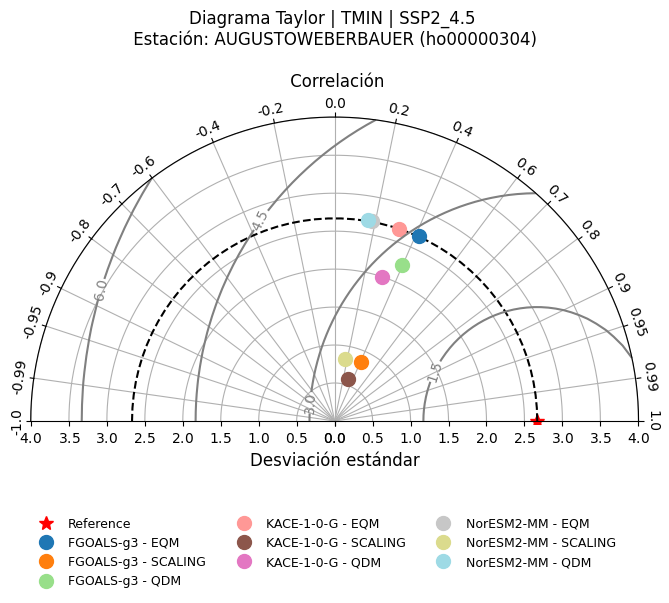

<Figure size 640x480 with 0 Axes>

In [29]:
generar_taylor_met4_masivo(
    ruta_carpeta=ruta_downscaling,
    df_obs_completo=df_sierra,
    codigo_estacion=estacion_objetivo,
    variable='tmin',
    escenario='ssp2_4.5' # Opcional
)


--- Iniciando Met 4: ho00000304 | TMAX | SSP2_4.5 ---
✅ Modelo cargado: FGOALS-g3
✅ Modelo cargado: KACE-1-0-G
✅ Modelo cargado: NorESM2-MM
📊 Evaluando 9 técnicas en total. Días válidos sincronizados: 12172


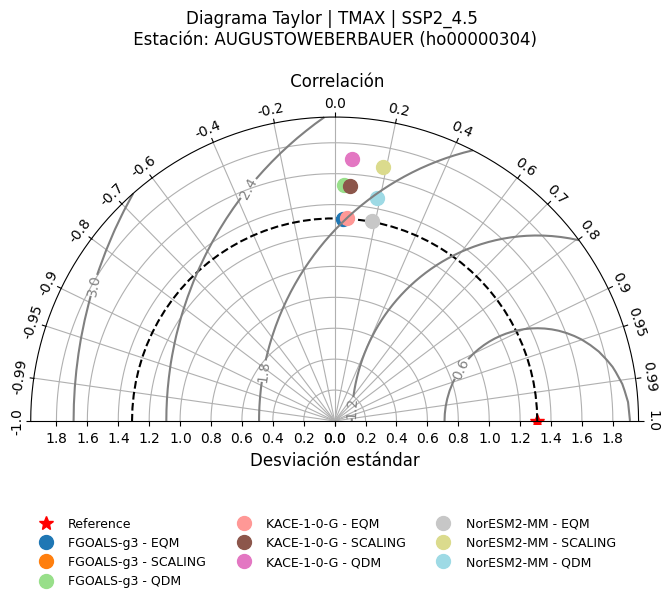

<Figure size 640x480 with 0 Axes>

In [30]:
generar_taylor_met4_masivo(
    ruta_carpeta=ruta_downscaling,
    df_obs_completo=df_sierra,
    codigo_estacion=estacion_objetivo,
    variable='tmax',
    escenario='ssp2_4.5' # Opcional
)


--- Iniciando Met 4: ho00000304 | PP | SSP2_4.5 ---
✅ Modelo cargado: FGOALS-g3
✅ Modelo cargado: KACE-1-0-G
✅ Modelo cargado: NorESM2-MM
📊 Evaluando 9 técnicas en total. Días válidos sincronizados: 12172


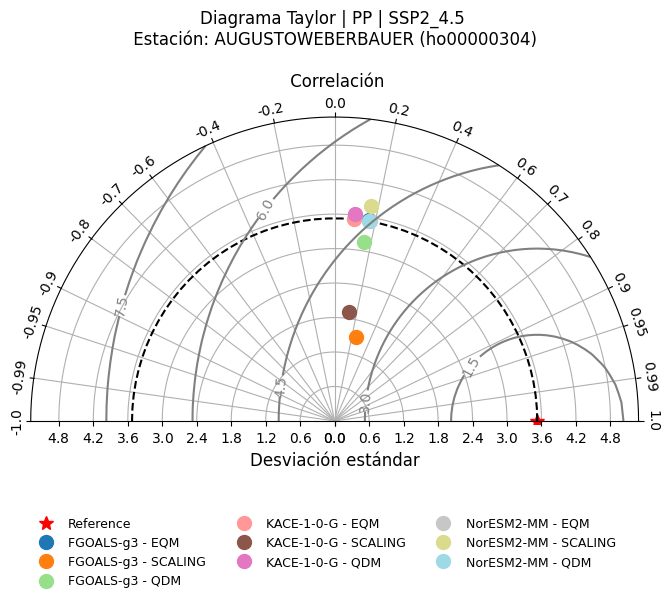

<Figure size 640x480 with 0 Axes>

In [31]:
generar_taylor_met4_masivo(
    ruta_carpeta=ruta_downscaling,
    df_obs_completo=df_sierra,
    codigo_estacion=estacion_objetivo,
    variable='pp',
    escenario='ssp2_4.5' # Opcional
)

In [32]:
codigos = df_sierra["Codigo"].unique()
codigos

array(['ho00000304', 'ho00000237', 'ho00000362', 'ho00000373',
       'ho00000354', 'ho00000352', 'ho00000343', 'ho00000239',
       'ho00000248', 'ho00000307', 'ho00000341', 'ho00000388',
       'ho00000321', 'ho00000369', 'ho00000370', 'ho00000351'],
      dtype=object)

In [33]:
for codigo in codigos:
  generar_taylor_met4_masivo(
      ruta_carpeta=ruta_downscaling,
      df_obs_completo=df_sierra,
      codigo_estacion=codigo,
      variable='tmin',
      escenario='ssp2_4.5' # Opcional
  )

Output hidden; open in https://colab.research.google.com to view.